# Titration MCQ

---

## The question

A student pipettes **25.00 mL of hydrochloric acid** of unknown concentration into
a conical flask, adds two drops of **phenolphthalein**, and titrates it against
**0.100 M NaOH** from a 50 mL burette, swirling over a white tile.

$$\mathrm{HCl(aq)} + \mathrm{NaOH(aq)} \longrightarrow \mathrm{NaCl(aq)} + \mathrm{H_2O(l)}$$

| burette reading | volume |
|---|---|
| initial | **0.40 mL** |
| final (first permanent pink) | **23.90 mL** |

**What is the concentration of the hydrochloric acid?**

**A.** 0.0940 mol/L  
**B.** 0.0956 mol/L  
**C.** 0.100 mol/L  
**D.** 0.106 mol/L

The apparatus is drawn below - have a look at the burette scale before you answer.


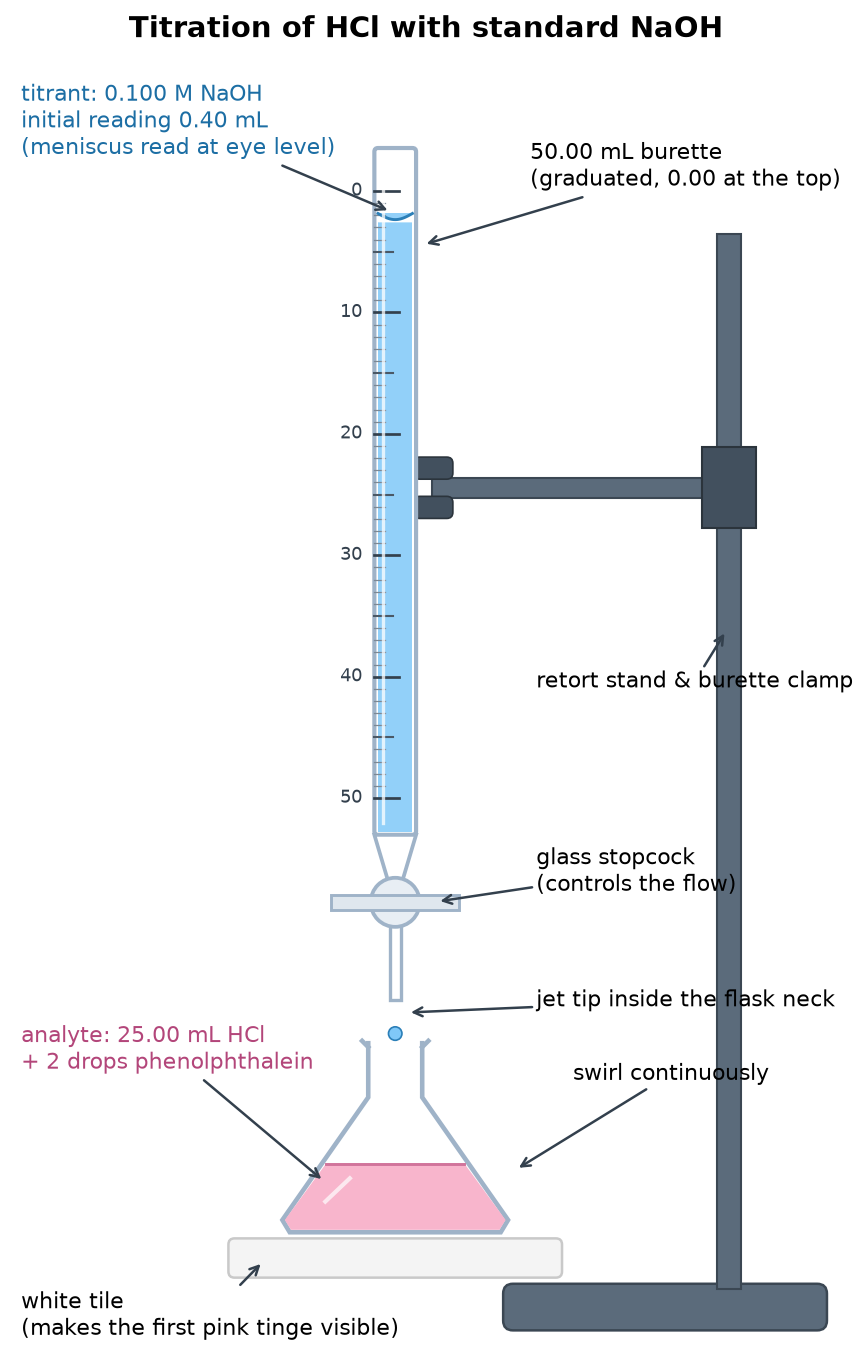

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, FancyBboxPatch, Circle

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "font.family": "DejaVu Sans"})

# ---- the numbers of this experiment -------------------------------------
V_ACID        = 25.00     # mL of HCl pipetted into the flask
C_BASE        = 0.100     # mol/L standard NaOH in the burette
BURETTE_START = 0.40      # mL, initial reading
BURETTE_END   = 23.90     # mL, reading at the first permanent pink

def draw_setup(fill_frac: float = 0.965, save: str | None = None):
    """Draw a labelled titration set-up: stand, clamp, filled burette, flask.

    fill_frac : how full the burette looks (0 = empty, 1 = up to the 0.00 mark)
    """
    fig, ax = plt.subplots(figsize=(7.2, 9.2))
    ax.set_xlim(-3.1, 3.6)
    ax.set_ylim(-0.9, 9.6)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_facecolor("white")

    GLASS = "#9fb3c8"
    TITRANT = "#7fc8f8"
    ANALYTE = "#f7a8c4"
    STEEL = "#5b6b7b"

    # ---------------- retort stand -------------------------------------
    ax.add_patch(FancyBboxPatch((0.9, -0.72), 2.6, 0.34,
                                boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=STEEL, edgecolor="#3b4753", lw=1.2,
                                zorder=1))
    ax.add_patch(Rectangle((2.62, -0.4), 0.20, 8.6, facecolor=STEEL,
                           edgecolor="#3b4753", lw=1.0, zorder=1))
    # clamp arm + boss head
    ax.add_patch(Rectangle((0.30, 6.05), 2.36, 0.16, facecolor=STEEL,
                           edgecolor="#3b4753", lw=1.0, zorder=3))
    ax.add_patch(Rectangle((2.50, 5.80), 0.44, 0.66, facecolor="#42505e",
                           edgecolor="#2b343c", lw=1.0, zorder=4))
    # jaws gripping the burette
    for dy in (-0.13, 0.19):
        ax.add_patch(FancyBboxPatch((0.16, 6.02 + dy), 0.30, 0.16,
                                    boxstyle="round,pad=0.01,rounding_size=0.05",
                                    facecolor="#42505e", edgecolor="#2b343c",
                                    lw=0.8, zorder=4))

    # ---------------- burette barrel -----------------------------------
    bx, bw = -0.17, 0.34            # left edge, width
    y_top, y_bot = 8.90, 3.30       # barrel
    ax.add_patch(FancyBboxPatch((bx, y_bot), bw, y_top - y_bot,
                                boxstyle="round,pad=0.0,rounding_size=0.03",
                                facecolor="white", edgecolor=GLASS, lw=2.0,
                                zorder=5))

    # graduated scale: 0.00 mL at the top, 50 mL at the bottom of the barrel
    y0, y50 = 8.55, 3.60
    for mL in range(0, 51):
        y = y0 + (y50 - y0) * mL / 50.0
        if mL % 10 == 0:
            ax.plot([bx, bx + 0.20], [y, y], color="#33404d", lw=1.3, zorder=8)
            ax.text(bx - 0.10, y, f"{mL}", ha="right", va="center",
                    fontsize=8.5, color="#33404d", zorder=8)
        elif mL % 5 == 0:
            ax.plot([bx, bx + 0.15], [y, y], color="#4a5866", lw=1.0, zorder=8)
        else:
            ax.plot([bx, bx + 0.09], [y, y], color="#7b8895", lw=0.6, zorder=8)

    # ---------------- titrant inside the burette -----------------------
    y_men = y_bot + fill_frac * (y0 - y_bot)          # meniscus height
    ax.add_patch(Rectangle((bx + 0.03, y_bot + 0.02), bw - 0.06,
                           y_men - y_bot - 0.02, facecolor=TITRANT,
                           edgecolor="none", alpha=0.85, zorder=6))
    # concave meniscus
    xm = np.linspace(bx + 0.03, bx + bw - 0.03, 60)
    dip = 0.05 * np.cos(np.pi * (xm - bx - bw / 2) / (bw - 0.06))
    ax.fill_between(xm, y_men - 0.06, y_men - dip, color="white", zorder=7)
    ax.plot(xm, y_men - dip, color="#2b7fb8", lw=1.4, zorder=8)
    # glass highlight
    ax.plot([bx + 0.07, bx + 0.07], [y_bot + 0.1, y_top - 0.15],
            color="white", lw=1.6, alpha=0.75, zorder=8)

    # ---------------- stopcock + delivery tip --------------------------
    ax.add_patch(Polygon([[bx, y_bot], [bx + bw, y_bot],
                          [bx + bw / 2 + 0.045, y_bot - 0.42],
                          [bx + bw / 2 - 0.045, y_bot - 0.42]],
                         closed=True, facecolor="white", edgecolor=GLASS,
                         lw=1.8, zorder=5))
    ax.add_patch(Circle((0.0, y_bot - 0.55), 0.20, facecolor="#e8eef4",
                        edgecolor=GLASS, lw=1.8, zorder=6))
    ax.add_patch(Rectangle((-0.52, y_bot - 0.61), 1.04, 0.12,
                           facecolor="#dfe7ee", edgecolor=GLASS, lw=1.4,
                           zorder=7))
    ax.add_patch(Rectangle((-0.045, y_bot - 1.35), 0.09, 0.72,
                           facecolor="white", edgecolor=GLASS, lw=1.6, zorder=5))
    # a drop on its way down
    ax.add_patch(Circle((0.0, y_bot - 1.62), 0.055, facecolor=TITRANT,
                        edgecolor="#2b7fb8", lw=0.8, zorder=6))

    # ---------------- conical (Erlenmeyer) flask -----------------------
    neck_w, neck_top, neck_bot = 0.22, 1.62, 1.16
    body_w, base_y = 0.92, 0.06
    flask = [(-neck_w, neck_top), (-neck_w, neck_bot), (-body_w, base_y + 0.10),
             (-body_w + 0.06, base_y), (body_w - 0.06, base_y),
             (body_w, base_y + 0.10), (neck_w, neck_bot), (neck_w, neck_top)]
    ax.add_patch(Polygon(flask, closed=False, facecolor="white",
                         edgecolor=GLASS, lw=2.2, zorder=5))
    ax.plot([-neck_w - 0.05, -neck_w], [neck_top, neck_top - 0.05],
            color=GLASS, lw=2.2, zorder=5)
    ax.plot([neck_w + 0.05, neck_w], [neck_top, neck_top - 0.05],
            color=GLASS, lw=2.2, zorder=5)

    # pink analyte: the level follows the cone
    lev = 0.62
    half = body_w - (body_w - neck_w) * (lev - base_y) / (neck_bot - base_y)
    soln = [(-body_w + 0.02, base_y + 0.10), (-body_w + 0.07, base_y + 0.02),
            (body_w - 0.07, base_y + 0.02), (body_w - 0.02, base_y + 0.10),
            (half, lev), (-half, lev)]
    ax.add_patch(Polygon(soln, closed=True, facecolor=ANALYTE, edgecolor="none",
                         alpha=0.85, zorder=6))
    ax.plot([-half, half], [lev, lev], color="#d1749b", lw=1.4, zorder=7)
    ax.plot([-body_w + 0.35, -body_w + 0.55], [base_y + 0.25, lev - 0.12],
            color="white", lw=2.0, alpha=0.7, zorder=8)

    # ---------------- white tile ---------------------------------------
    ax.add_patch(FancyBboxPatch((-1.35, -0.30), 2.70, 0.30,
                                boxstyle="round,pad=0.01,rounding_size=0.05",
                                facecolor="#f4f4f4", edgecolor="#c9c9c9",
                                lw=1.2, zorder=3))

    # ---------------- labels -------------------------------------------
    lab = dict(fontsize=10.5, va="center", zorder=10)
    arrow = dict(arrowstyle="->", color="#33404d", lw=1.2,
                 shrinkA=0, shrinkB=4)

    ax.annotate("50.00 mL burette\n(graduated, 0.00 at the top)",
                xy=(bx + bw + 0.02, 8.10), xytext=(1.10, 8.75),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate(f"titrant: {C_BASE:.3f} M NaOH\ninitial reading 0.40 mL\n(meniscus read at eye level)",
                xy=(bx + bw / 2, y_men), xytext=(-3.05, y_men + 0.75),
                arrowprops=arrow, ha="left", color="#1c6ea4", **lab)
    ax.annotate("glass stopcock\n(controls the flow)",
                xy=(0.30, y_bot - 0.55), xytext=(1.15, y_bot - 0.30),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate("jet tip inside the flask neck",
                xy=(0.06, y_bot - 1.45), xytext=(1.15, y_bot - 1.35),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate(f"analyte: {V_ACID:.2f} mL HCl\n+ 2 drops phenolphthalein",
                xy=(-0.55, 0.45), xytext=(-3.05, 1.55),
                arrowprops=arrow, ha="left", color="#b3467a", **lab)
    ax.annotate("white tile\n(makes the first pink tinge visible)",
                xy=(-1.05, -0.15), xytext=(-3.05, -0.62),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate("retort stand & burette clamp",
                xy=(2.72, 5.0), xytext=(1.15, 4.55),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate("swirl continuously",
                xy=(0.95, 0.55), xytext=(1.45, 1.35),
                arrowprops=arrow, ha="left", **lab)

    ax.set_title("Titration of HCl with standard NaOH", fontsize=14,
                 fontweight="bold", pad=12)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150, bbox_inches="tight")
    return fig, ax

fig, ax = draw_setup()
plt.show()


---

## Working

A titration calculation is always the same three steps:

1. **Titrant** - moles of the substance you know (the NaOH in the burette).
2. **Bridge** - cross over with the mole ratio from the balanced equation (here a
   friendly 1 : 1).
3. **Analyte** - divide by the flask volume to get the unknown concentration.

The only thing that makes this question *conceptual* rather than mechanical is
step 0: a burette measures a **position**, not an amount, so the volume delivered
is always **final − initial**.


In [4]:
titre  = BURETTE_END - BURETTE_START          # volume actually delivered
n_base = C_BASE * titre / 1000.0             # mol of NaOH
n_acid = n_base                              # 1 : 1 stoichiometry
c_acid = n_acid / (V_ACID / 1000.0)          # mol/L of HCl

print(f"titre    = {BURETTE_END:.2f} mL - {BURETTE_START:.2f} mL = {titre:.2f} mL")
print(f"n(NaOH)  = 0.100 mol/L x {titre/1000:.5f} L = {n_base*1000:.3f} mmol")
print(f"n(HCl)   = {n_acid*1000:.3f} mmol            (1 : 1)")
print(f"c(HCl)   = {n_acid*1000:.3f} mmol / {V_ACID:.2f} mL = {c_acid:.4f} mol/L")
print()
print(f"  ->  ANSWER: A   ({c_acid:.4f} mol/L)")
print()
print("Why the distractors are wrong:")
print(f"  B  {C_BASE*BURETTE_END/V_ACID:.4f} M  : uses 23.90 mL, forgetting to subtract")
print( "                     the initial burette reading of 0.40 mL")
print( "  C  0.1000 M  : assumes the acid must match the base")
print( "  D  0.1060 M  : divides 25.00 by 23.50 instead of the other way round")


titre    = 23.90 mL - 0.40 mL = 23.50 mL
n(NaOH)  = 0.100 mol/L x 0.02350 L = 2.350 mmol
n(HCl)   = 2.350 mmol            (1 : 1)
c(HCl)   = 2.350 mmol / 25.00 mL = 0.0940 mol/L

  ->  ANSWER: A   (0.0940 mol/L)

Why the distractors are wrong:
  B  0.0956 M  : uses 23.90 mL, forgetting to subtract
                     the initial burette reading of 0.40 mL
  C  0.1000 M  : assumes the acid must match the base
  D  0.1060 M  : divides 25.00 by 23.50 instead of the other way round


---

## The idea being tested

> **Volume delivered = final reading − initial reading.**

A burette is not a measuring cylinder. You never need it to start at exactly
0.00 mL - and topping it up mid-titration is fine for the same reason - because
only the *difference* is used. Option **B** is what you get by reading the final
number straight off the glass, which is the single most common titration slip.

Two small habits that go with it:

* read the **bottom of the meniscus at eye level** (looking down or up gives a
  parallax error);
* record **two decimal places** - a 50 mL burette is good to about ±0.05 mL, so
  `23.90` is honest and `23.9` throws away information.

*Companion file: `titration_mcq.py` - prints the question, the working and the
answer, and saves the same diagram as a PNG.*
